In [27]:
# Imports and Setup

from glass_dynamics.core.logger import logger

from glass_dynamics.data.processor import filter_and_fit_dataset
from glass_dynamics.data.composition import gen_atomic_df
from glass_dynamics.data.splitting import split_by_cassar_indices, split_by_random_seed

from glass_dynamics.features.generator import generate_all_features, generate_cassar_35_features
from glass_dynamics.features.correlation import select_features_from_clusters
from glass_dynamics.features.vif import calculate_vif, calculate_ridge_vif, iterative_vif_selection, fast_iterative_vif_selection

from glass_dynamics.analysis.performance import compute_alpha_performance_metrics
from glass_dynamics.analysis.traces import compute_weight_traces
from glass_dynamics.analysis.feature_importance import extract_importance
from glass_dynamics.analysis.evolution import extract_top_features_evolution
from glass_dynamics.analysis.extrapolation import generate_extrapolation_metrics
from glass_dynamics.analysis.myega_bootstrap import generate_bootstrap_predictions
from glass_dynamics.analysis.elastic_net_grid import compute_elastic_net_grid_metrics
from glass_dynamics.analysis.pcr_grid import extract_pc_representatives
from glass_dynamics.analysis.spcr_grid import compute_spcr_components_metrics_target
from glass_dynamics.analysis.spcr_grid import extract_spcr_representatives
from glass_dynamics.analysis.pcr_viscosity_grid import compute_global_viscosity_p_grid

from glass_dynamics.visualization.features_exploration_plots import plot_pearson_correlation, generate_feature_metadata_table
from glass_dynamics.visualization.performance_plots import plot_target_performance
from glass_dynamics.visualization.traces_plots import plot_normalized_traces
from glass_dynamics.visualization.importance_plots import plot_sorted_feature_importance
from glass_dynamics.visualization.evolution_plots import plot_top_features_evolution
from glass_dynamics.visualization.density_plots import plot_viscosity_density_correlation
from glass_dynamics.visualization.distance_plots import plot_rmse_vs_distance_square
from glass_dynamics.visualization.viscosity_grids import plot_viscosity_grids_bootstrap
from glass_dynamics.visualization.elastic_net_plots import plot_elastic_net_3d_performance
from glass_dynamics.visualization.pcr_plots import plot_pcr_performance
from glass_dynamics.visualization.pcr_importance_plots import plot_sorted_pc_importance
from glass_dynamics.visualization.pcr_viscosity_plots import plot_global_viscosity_p_grid


from glass_dynamics.models.ridge import CustomRidgeRegression
from glass_dynamics.models.elastic_net import CustomElasticNet
from glass_dynamics.models.pcr import CustomPCR
from glass_dynamics.models.supervised_pcr import CustomSupervisedPCR
from sklearn.multioutput import MultiOutputRegressor

from glass_dynamics.evaluation.model_evaluation import evaluate_final_model

from glass_dynamics.utils.naming import generate_glass_names

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from pathlib import Path
import pickle


analysis_name = "spcr_analysis"

data_path = Path(f"../../data/cassar_split/base_analysis")
plots_path = Path(f"../../plots/spcr/{analysis_name}")
model_path = Path(f"../../models/spcr/{analysis_name}")
plots_path.mkdir(parents=True, exist_ok=True)
data_path.mkdir(parents=True, exist_ok=True)
model_path.mkdir(parents=True, exist_ok=True)


In [2]:
# Data Loading
logger.info("Loading raw datasets...")

raw_data = pd.read_csv('../../data/viscosity_raw_data.csv', index_col=0) 
chemical_props_T = pd.read_csv("../../data/chemical_properties.csv", index_col=0).T
chemical_props = pd.read_csv("../../data/chemical_properties.csv", index_col=0)
# raw_data


[INFO] 2026-09-24 09:51:05 - Loading raw datasets...


In [3]:
# MYEGA Fit and Filter
clean_glasses_df, rejected_glasses_df = filter_and_fit_dataset(raw_data, min_r2_threshold=0.95)
y_targets = clean_glasses_df[['ID', 'Tg_fitted', 'm_fitted', 'log_eta_inf_fitted']].set_index('ID')
oxides_df = clean_glasses_df.drop(columns=['Tg_fitted', 'm_fitted', 'log_eta_inf_fitted', 'myega_r2', 'myega_rmse']).set_index('ID')
# oxides_df


[INFO] 2026-09-24 09:51:05 - Starting data processing and MYEGA fitting on 847 unique glasses...
[INFO] 2026-09-24 09:51:28 - Processing complete. Accepted glasses: 847. Rejected glasses: 0.


In [4]:
# Convert Oxides to Elements
atomic_df = gen_atomic_df(oxides_df, chemical_props_T)
# atomic_df


[INFO] 2026-09-24 09:51:28 - Converting compound fractions to elemental atomic fractions using chemparse...
[INFO] 2026-09-24 09:51:28 - Successfully converted. Output shape: (847, 59)


In [5]:
# # Generate cassar viscnet features
# X_cassar_features = generate_cassar_35_features(atomic_df, chemical_props)
# X_cassar_features

In [6]:
# This generates 560 features
X_all_features = generate_all_features(atomic_df, chemical_props)
# X_all_features


[INFO] 2026-09-24 09:51:28 - Generating all W and A features from 56 chemical properties...
[INFO] 2026-09-24 09:53:06 - Feature generation complete. Total features created: 560


In [7]:
# Data splitting
X_train, X_test, y_train, y_test = split_by_cassar_indices(X_all_features, y_targets, "../../data/cassar_split/test_ids.parquet")
# X_test

[INFO] 2026-09-24 09:53:06 - Splitting dataset using predefined indices from ../../data/cassar_split/test_ids.parquet...
[INFO] 2026-09-24 09:53:06 - Split complete. Train size: 762, Test size: 85


In [8]:
# Standardize features and output
X_scaler = StandardScaler().set_output(transform="pandas")
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = StandardScaler().set_output(transform="pandas")
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

# y_test_scaled

In [9]:
# Saving data

X_train_scaled.to_parquet(data_path / 'X_train.parquet')
X_test_scaled.to_parquet(data_path / 'X_test.parquet')

y_train.to_parquet('../../data/cassar_split/y_train.parquet')
y_test.to_parquet('../../data/cassar_split/y_test.parquet')

[INFO] 2026-09-24 09:53:07 - Computing SPCR metrics across 29 configurations for 3 targets.
[INFO] 2026-09-24 09:53:07 - Optimizing Supervised Subspace for target: Tg_fitted
[INFO] 2026-09-24 09:53:21 - Optimizing Supervised Subspace for target: m_fitted
[INFO] 2026-09-24 09:53:36 - Optimizing Supervised Subspace for target: log_eta_inf_fitted
[INFO] 2026-09-24 09:53:50 - Rendering PCR performance plots for Tg_fitted.
[INFO] 2026-09-24 09:53:52 - Rendering PCR performance plots for m_fitted.
[INFO] 2026-09-24 09:53:52 - Rendering PCR performance plots for log_eta_inf_fitted.


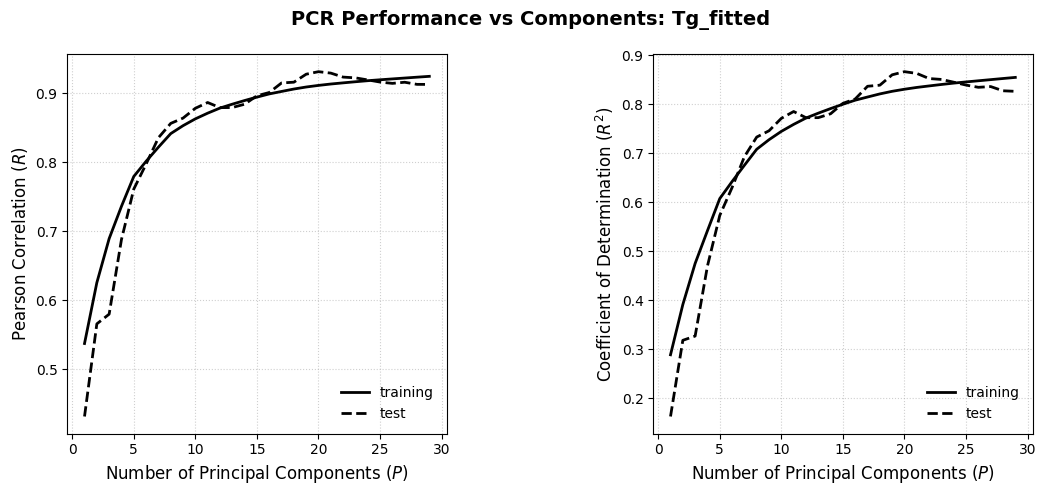

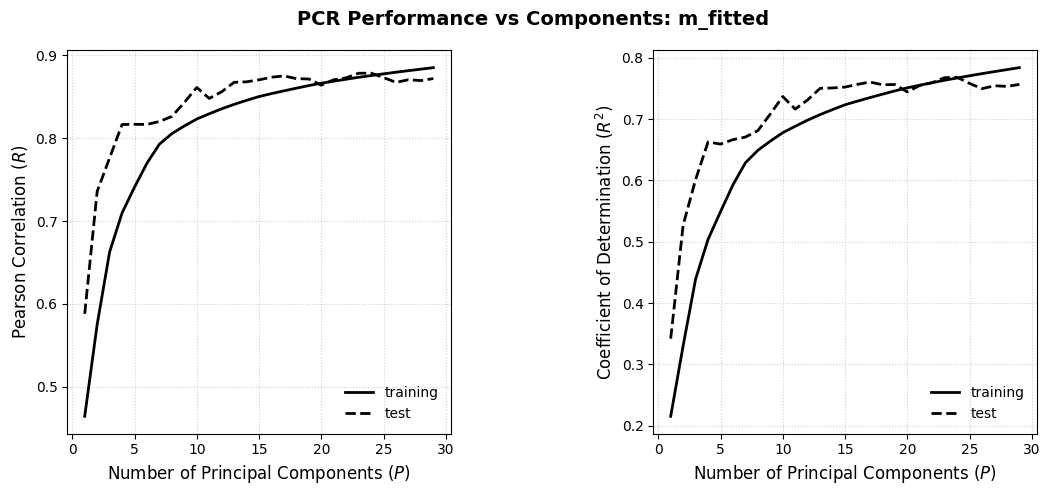

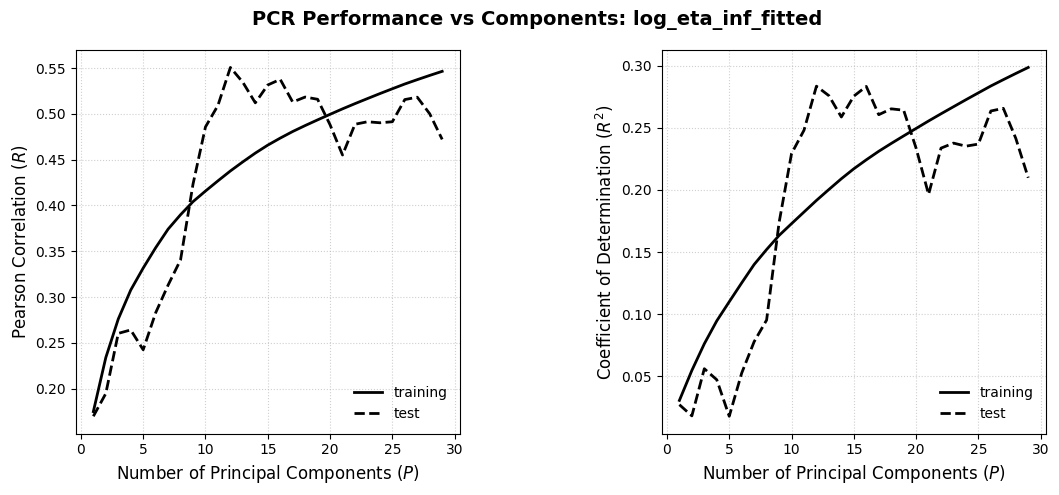

In [10]:
p_spectrum = np.arange(1, 30, 1) # [1, 3, 5, 7, ..., 99]

# Calcoliamo le metriche con la PCR Supervisionata
spcr_metrics = compute_spcr_components_metrics_target(
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    p_array=p_spectrum
)

spcr_plots_path = plots_path / "spcr_performance_plots"
spcr_plots_path.mkdir(parents=True, exist_ok=True)

for target in spcr_metrics.keys():
    # Riutilizziamo plot_pcr_performance (l'estetica va bene per entrambe)
    fig_spcr = plot_pcr_performance(spcr_metrics[target], target_name=target)
    fig_spcr.savefig(spcr_plots_path / f"{target}_SPCR_Performance.pdf", bbox_inches='tight')

Extracting Supervised PCs for Tg_fitted...
[INFO] 2026-09-24 10:08:04 - Extracting robust features using CustomSupervisedPCR over 100 splits.
Extracting Supervised PCs for m_fitted...
[INFO] 2026-09-24 10:08:19 - Extracting robust features using CustomSupervisedPCR over 100 splits.
Extracting Supervised PCs for log_eta_inf_fitted...
[INFO] 2026-09-24 10:08:30 - Extracting robust features using CustomSupervisedPCR over 100 splits.
[INFO] 2026-09-24 10:08:40 - Rendering sorted raw feature importance S-curves for 3 targets.


,feature,original_index,weight,std,abs_weight
0,A_Max_FusionEnthalpy,375,-0.044213,0.016191,0.044213
1,W_Max_SpaceGroupNumber,550,-0.043388,0.016022,0.043388
2,W_Max_num_oxistates,340,-0.039355,0.013814,0.039355
3,W_Sum_ElectronAffinity,354,-0.037456,0.008428,0.037456
4,W_Std_SpaceGroupNumber,553,-0.037405,0.013527,0.037405
5,W_Sum_num_oxistates,344,-0.037044,0.008862,0.037044
6,A_Std_FusionEnthalpy,378,-0.035574,0.009062,0.035574
7,W_Max_FusionEnthalpy,370,-0.035340,0.007717,0.035340
8,W_Sum_SpaceGroupNumber,554,-0.032409,0.009949,0.032409
9,A_Max_mendeleev_number,205,0.029962,0.014991,0.029962


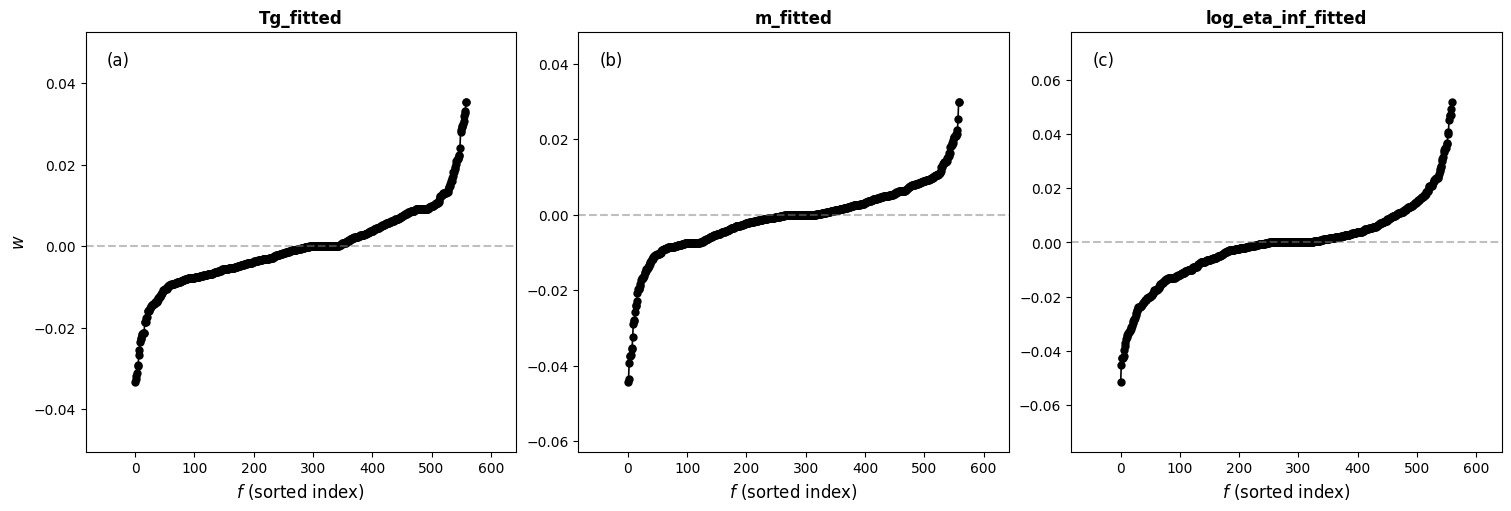

In [26]:
# Feature weights plots (ordered)
target_names = y_train_scaled.columns.tolist()
spcr_results = {}

spcr_model = CustomSupervisedPCR(n_components=10)
for target in target_names:
    print(f"Extracting Supervised PCs for {target}...")

    # Passiamo SOLO la colonna del target specifico
    y_single_target = y_train_scaled[[target]]

    # Sfruttiamo la nostra funzione universale!
    importance = extract_importance(
        X=X_train_scaled,
        y=y_single_target,
        base_model=spcr_model,
        n_splits=100
    )

    # Salviamo il risultato per questo target
    spcr_results[target] = importance[target]

fig_importance = plot_sorted_feature_importance(spcr_results, top_n=0)
fig_importance.savefig(plots_path / 'features_importance_pcr.pdf', bbox_inches='tight')


spcr_results['m_fitted'].head(20) # log_eta_inf
# print("\nTop 10 features per Tg_fitted:")
# print(importance_data['Tg_fitted'].head(10)[['original_index', 'feature', 'weight', 'abs_weight']])

In [37]:
ottimali_p = 10

spcr_representatives = extract_spcr_representatives(
    X_train=X_train_scaled, 
    y_train=y_train_scaled, 
    n_components=ottimali_p,
    variance_threshold=1e-4  # Protezione contro il rumore
)

print("Top Principal Components for Tg (Sorted by Importance):")
display(spcr_representatives['log_eta_inf_fitted'].head(15))

Top Principal Components for Tg (Sorted by Importance):


,Component,Regression_Weight,Abs_Weight,Target_Correlation,Explained_Variance_%,Top_Representative_Feature,Feature_Loading
0,PC60,0.370488,0.370488,0.123943,0.021774,A_Mean_GSmagmom,0.163931
1,PC46,-0.243323,0.243323,0.123269,0.049932,A_Std_vdw_radius_uff,0.231702
2,PC34,0.197487,0.197487,0.155320,0.120342,W_Sum_GSmagmom,0.178331
3,PC18,-0.072171,0.072171,0.121668,0.552924,A_Std_calc_en_sanderson,0.189326
4,PC16,-0.068766,0.068766,0.135855,0.759342,W_Max_atomic_radius,0.192752
5,PC15,0.052864,0.052864,0.106363,0.787602,W_Std_NValence,0.159464
6,PC9,-0.052756,0.052756,0.175015,2.141127,A_Sum_GSmagmom,0.188133
7,PC7,0.025783,0.025783,0.097374,2.774911,A_Mean_NdUnfilled,0.135349
8,PC6,0.024181,0.024181,0.109732,4.006467,A_Std_zeff,0.125635
9,PC3,0.018057,0.018057,0.146409,12.790555,W_Sum_atomic_radius,0.116570


[INFO] 2026-09-24 10:06:25 - Rendering sorted PC importance S-curves for 3 targets.


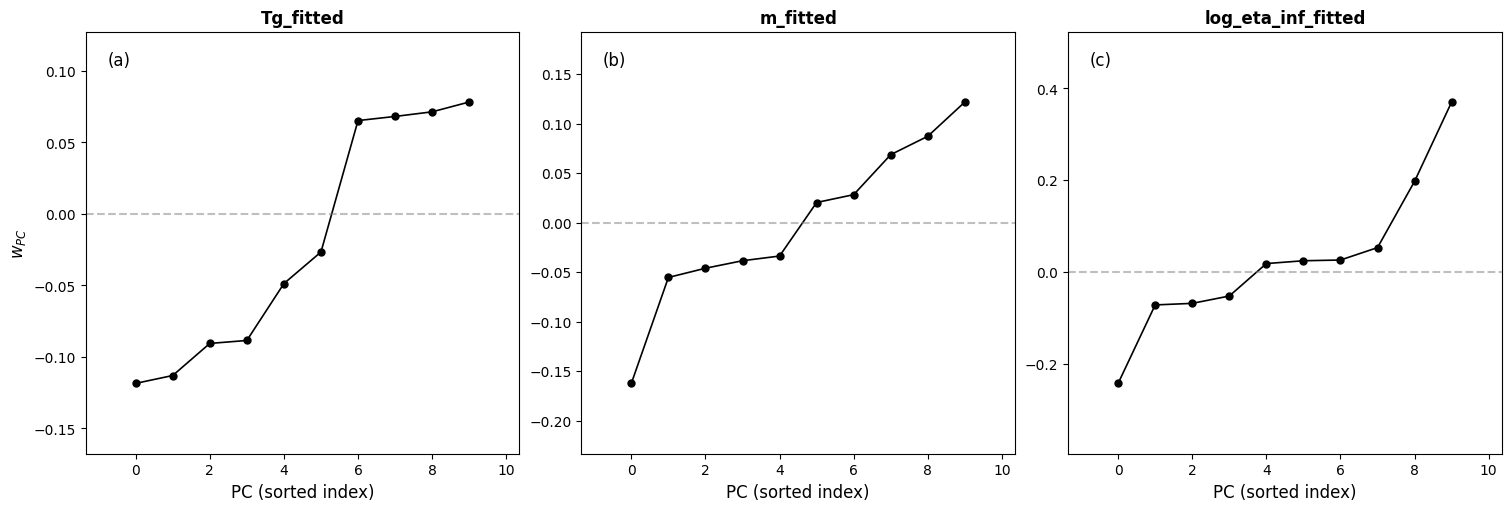

In [24]:
# # Top PC analysis

# Se hai 500 features, puoi estrarre tutte le componenti o un numero sufficientemente alto
# per vedere l'intera S-curve della PCR
ottimali_p = 10

spcr_representatives_full = extract_spcr_representatives(
    X_train=X_train_scaled, 
    y_train=y_train_scaled, 
    n_components=ottimali_p,
    variance_threshold=1e-4  # Protezione contro il rumore
)

# Plot S-Curve senza annotazioni, come da tua richiesta
fig_spcr_importance = plot_sorted_pc_importance(
    pc_dict=spcr_representatives_full, 
    top_n=0
)

fig_spcr_importance.savefig(spcr_plots_path / "SPCR_S_Curve_Importance.pdf", bbox_inches='tight')

In [28]:
# Training model
spcr_model = MultiOutputRegressor(
    CustomSupervisedPCR(n_components=10, variance_threshold=1e-4)
)
spcr_model.fit(X_train_scaled, y_train_scaled)

pickle.dump(spcr_model, open(model_path / "spcr_model.pkl", 'wb'))

logger.info("Model successfully trained and saved!")  

[INFO] 2026-09-24 10:20:18 - Model successfully trained and saved!


Valutazione Dimensionalità PCR...
[INFO] 2026-09-24 10:20:57 - Computing train and test global viscosity metrics across 14 configurations for CustomPCR.
Valutazione Dimensionalità SPCR...
[INFO] 2026-09-24 10:21:02 - Computing train and test global viscosity metrics across 14 configurations for CustomSupervisedPCR.
[INFO] 2026-09-24 10:21:17 - Rendering global viscosity dimensionality plots for Classical PCR.
[INFO] 2026-09-24 10:21:18 - Rendering global viscosity dimensionality plots for Supervised PCR.


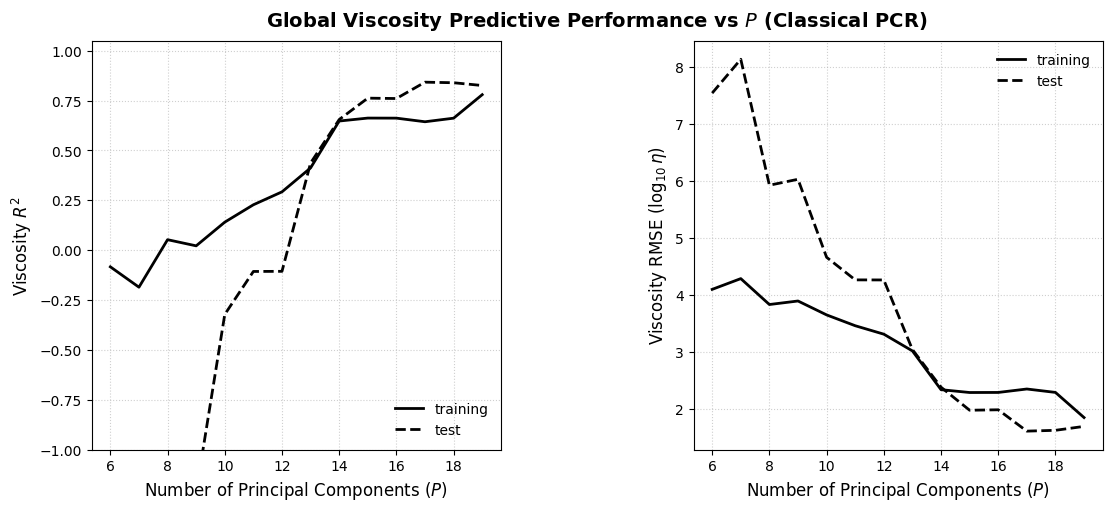

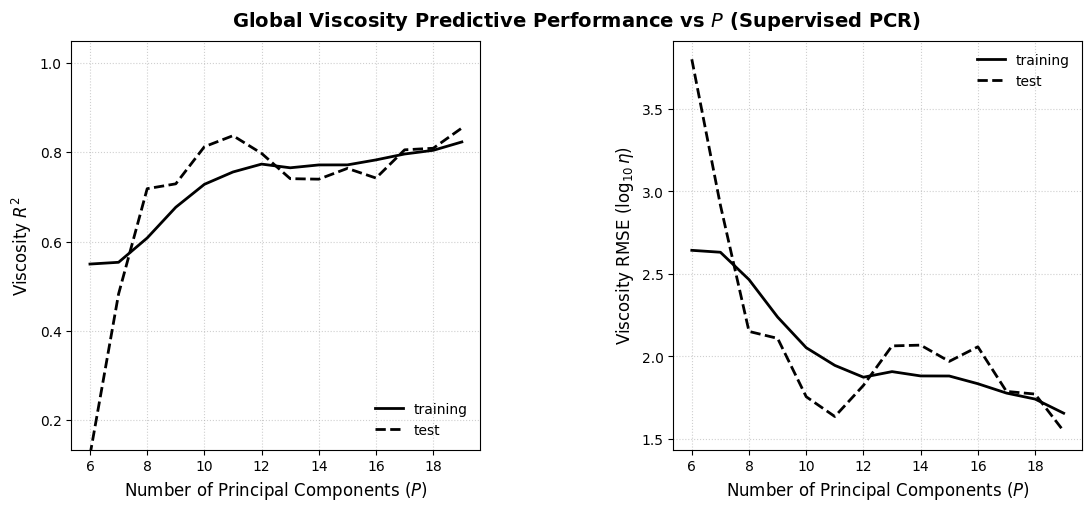

In [30]:
# 1. Definiamo lo spettro di componenti
p_spectrum = np.arange(6, 20, 1) 

# 2. Inizializziamo i due modelli vuoti
# Per la SPCR manteniamo la soglia di varianza per evitare overfitting catastrofico
model_pcr = CustomPCR(fit_intercept=True)
model_spcr = CustomSupervisedPCR(variance_threshold=1e-4, fit_intercept=True)

# 3. Calcoliamo l'errore globale di viscosità per la PCR Classica
print("Valutazione Dimensionalità PCR...")
viscosity_metrics_pcr = compute_global_viscosity_p_grid(
    base_model=model_pcr,
    p_array=p_spectrum,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data, # il dataset con ID, T, log_visc
    y_scaler=y_scaler
)

# 4. Calcoliamo l'errore globale di viscosità per la SPCR Supervisionata
print("Valutazione Dimensionalità SPCR...")
viscosity_metrics_spcr = compute_global_viscosity_p_grid(
    base_model=model_spcr,
    p_array=p_spectrum,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data,
    y_scaler=y_scaler
)

# 5. Visualizzazione e Salvataggio
viscosity_plots_path = plots_path / "global_viscosity_p_grid"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

fig_pcr = plot_global_viscosity_p_grid(viscosity_metrics_pcr, model_name="Classical PCR")
fig_pcr.savefig(viscosity_plots_path / "PCR_Global_Viscosity_Performance.pdf", bbox_inches='tight')

fig_spcr = plot_global_viscosity_p_grid(viscosity_metrics_spcr, model_name="Supervised PCR")
fig_spcr.savefig(viscosity_plots_path / "SPCR_Global_Viscosity_Performance.pdf", bbox_inches='tight')

In [31]:
# Evaluating model

target_columns = ['Tg', 'm','log_eta_inf']

spcr_model_base = MultiOutputRegressor(
    CustomSupervisedPCR(n_components=10, variance_threshold=1e-4)
)

evaluation_metrics = evaluate_final_model(
    model=spcr_model_base,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_test=y_test_scaled,
    viscosity_df=raw_data, # il tuo dataset originale che contiene 'ID', 'T', 'log_visc'
    y_scaler=y_scaler,
    target_cols=y_train_scaled.columns.tolist()
)

[INFO] 2026-09-24 10:21:23 - Training and Evaluating MultiOutputRegressor on the unseen Test Set (85 glasses)...

      TEST SET PERFORMANCE (SCALED PARAMETERS)
Target: Tg_fitted
  Pearson : 0.879
  R^2     : 0.772
  RMSE    : 0.451
  MAE     : 0.319
  MedAE   : 0.266
--------------------------------------------------
Target: m_fitted
  Pearson : 0.861
  R^2     : 0.737
  RMSE    : 0.528
  MAE     : 0.414
  MedAE   : 0.371
--------------------------------------------------
Target: log_eta_inf_fitted
  Pearson : 0.486
  R^2     : 0.229
  RMSE    : 0.815
  MAE     : 0.597
  MedAE   : 0.428
--------------------------------------------------
[INFO] 2026-09-24 10:21:24 - Computing global viscosity performance via MYEGA equation...

      VISCOSITY: PREDICTED vs TRUE FITTED (MYEGA)
--------------------------------------------------
  Pearson : 0.933
  R^2     : 0.815
  RMSE    : 1.741
  MAE     : 1.197
  MedAE   : 0.784
      VISCOSITY: PREDICTED vs EXPERIMENTAL (GROUND TRUTH)
--------------

[INFO] 2026-09-24 10:21:29 - Rendering 2D density correlation plot with residual inset.


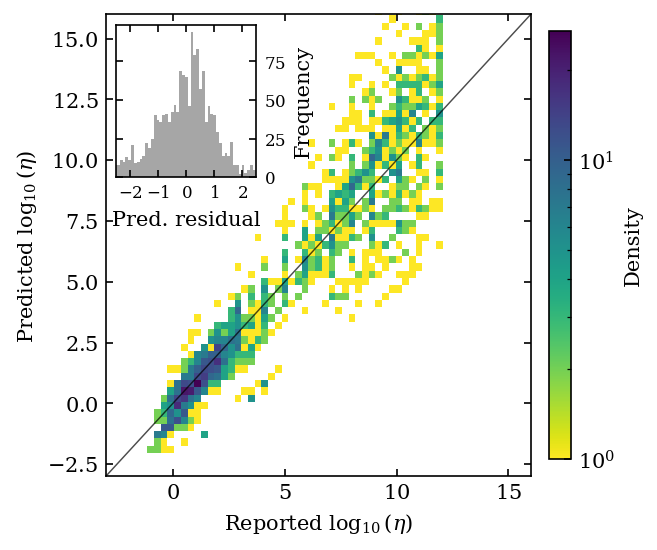

In [32]:
# Cassar density plot

y_true_visc = evaluation_metrics["viscosity_arrays"]["true_experimental"]
y_pred_visc = evaluation_metrics["viscosity_arrays"]["predicted_myega"]

fig_density = plot_viscosity_density_correlation(
    y_true=y_true_visc, 
    y_pred=y_pred_visc
)

fig_density.savefig(plots_path / '2D_density_histogram.pdf', bbox_inches='tight')
fig_density.savefig(plots_path / '2D_density_histogram.png', bbox_inches='tight')

[INFO] 2026-09-24 10:21:37 - Extracting distance and RMSE metrics into a DataFrame.


,ID,Name,Distance,RMSE
0,709,1Al₂O₃.50P₂O₅.18SrO.31ZnO,2.010101,6.053362
1,428,15Na₂O.27PbO.58SiO₂,0.095810,4.418186
2,483,13BaO.27Na₂O.60SiO₂,0.109890,4.212819
3,322,8Al₂O₃.3K₂O.4Na₂O.5P₂O₅.81SiO₂,0.551878,4.037727
4,233,7Al₂O₃.11BeO.3K₂O.4Na₂O.76SiO₂,1.227778,3.641949
5,806,51Li₂O.49P₂O₅,1.196148,3.440121
6,749,16Al₂O₃.2K₂O.1MgO.17Na₂O.7P₂O₅.58SiO₂,2.697277,3.336803
7,300,70GeO₂.20Na₂O.10PbO,0.276923,3.040079
8,201,50Na₂O.50P₂O₅,0.100251,2.829004
9,265,15Al₂O₃.65B₂O₃.20CaO,0.151111,2.796208


[INFO] 2026-09-24 10:21:37 - Rendering square scatter plot for Extrapolation Distance vs RMSE.


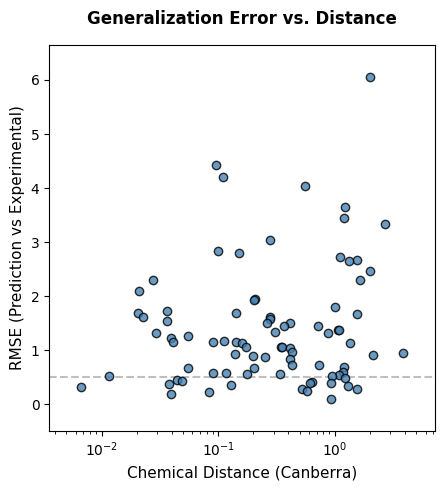

In [33]:
# Test glasses vs performance analysis

# Get glass names
compounds = raw_data.columns[:-3].tolist()
glass_names_dict = generate_glass_names(raw_data, compounds)

# Get model prediction
y_pred_scaled  = spcr_model.predict(X_test_scaled)

y_pred_physical = y_scaler.inverse_transform(y_pred_scaled)

target_columns = ['Tg', 'm','log_inf']

# Prediction dataframe
predictions_df = pd.DataFrame(
    y_pred_physical,
    columns=target_columns,
    index=y_test.index
)

# Generating distance data
metrics_df = generate_extrapolation_metrics(
    compounds=compounds,
    viscosity_df=raw_data,
    predictions_df=predictions_df, 
    names_dict=glass_names_dict
)
display(metrics_df.head(10))

# Generating distance plot
fig_distance = plot_rmse_vs_distance_square(metrics_df)
fig_distance.savefig(plots_path / 'distance_plot.pdf', bbox_inches='tight')

[INFO] 2026-09-24 10:22:15 - Training ensemble of 100 bootstrap models...
[INFO] 2026-09-24 10:23:24 - Rendering bootstrap prediction grids for 85 glasses.


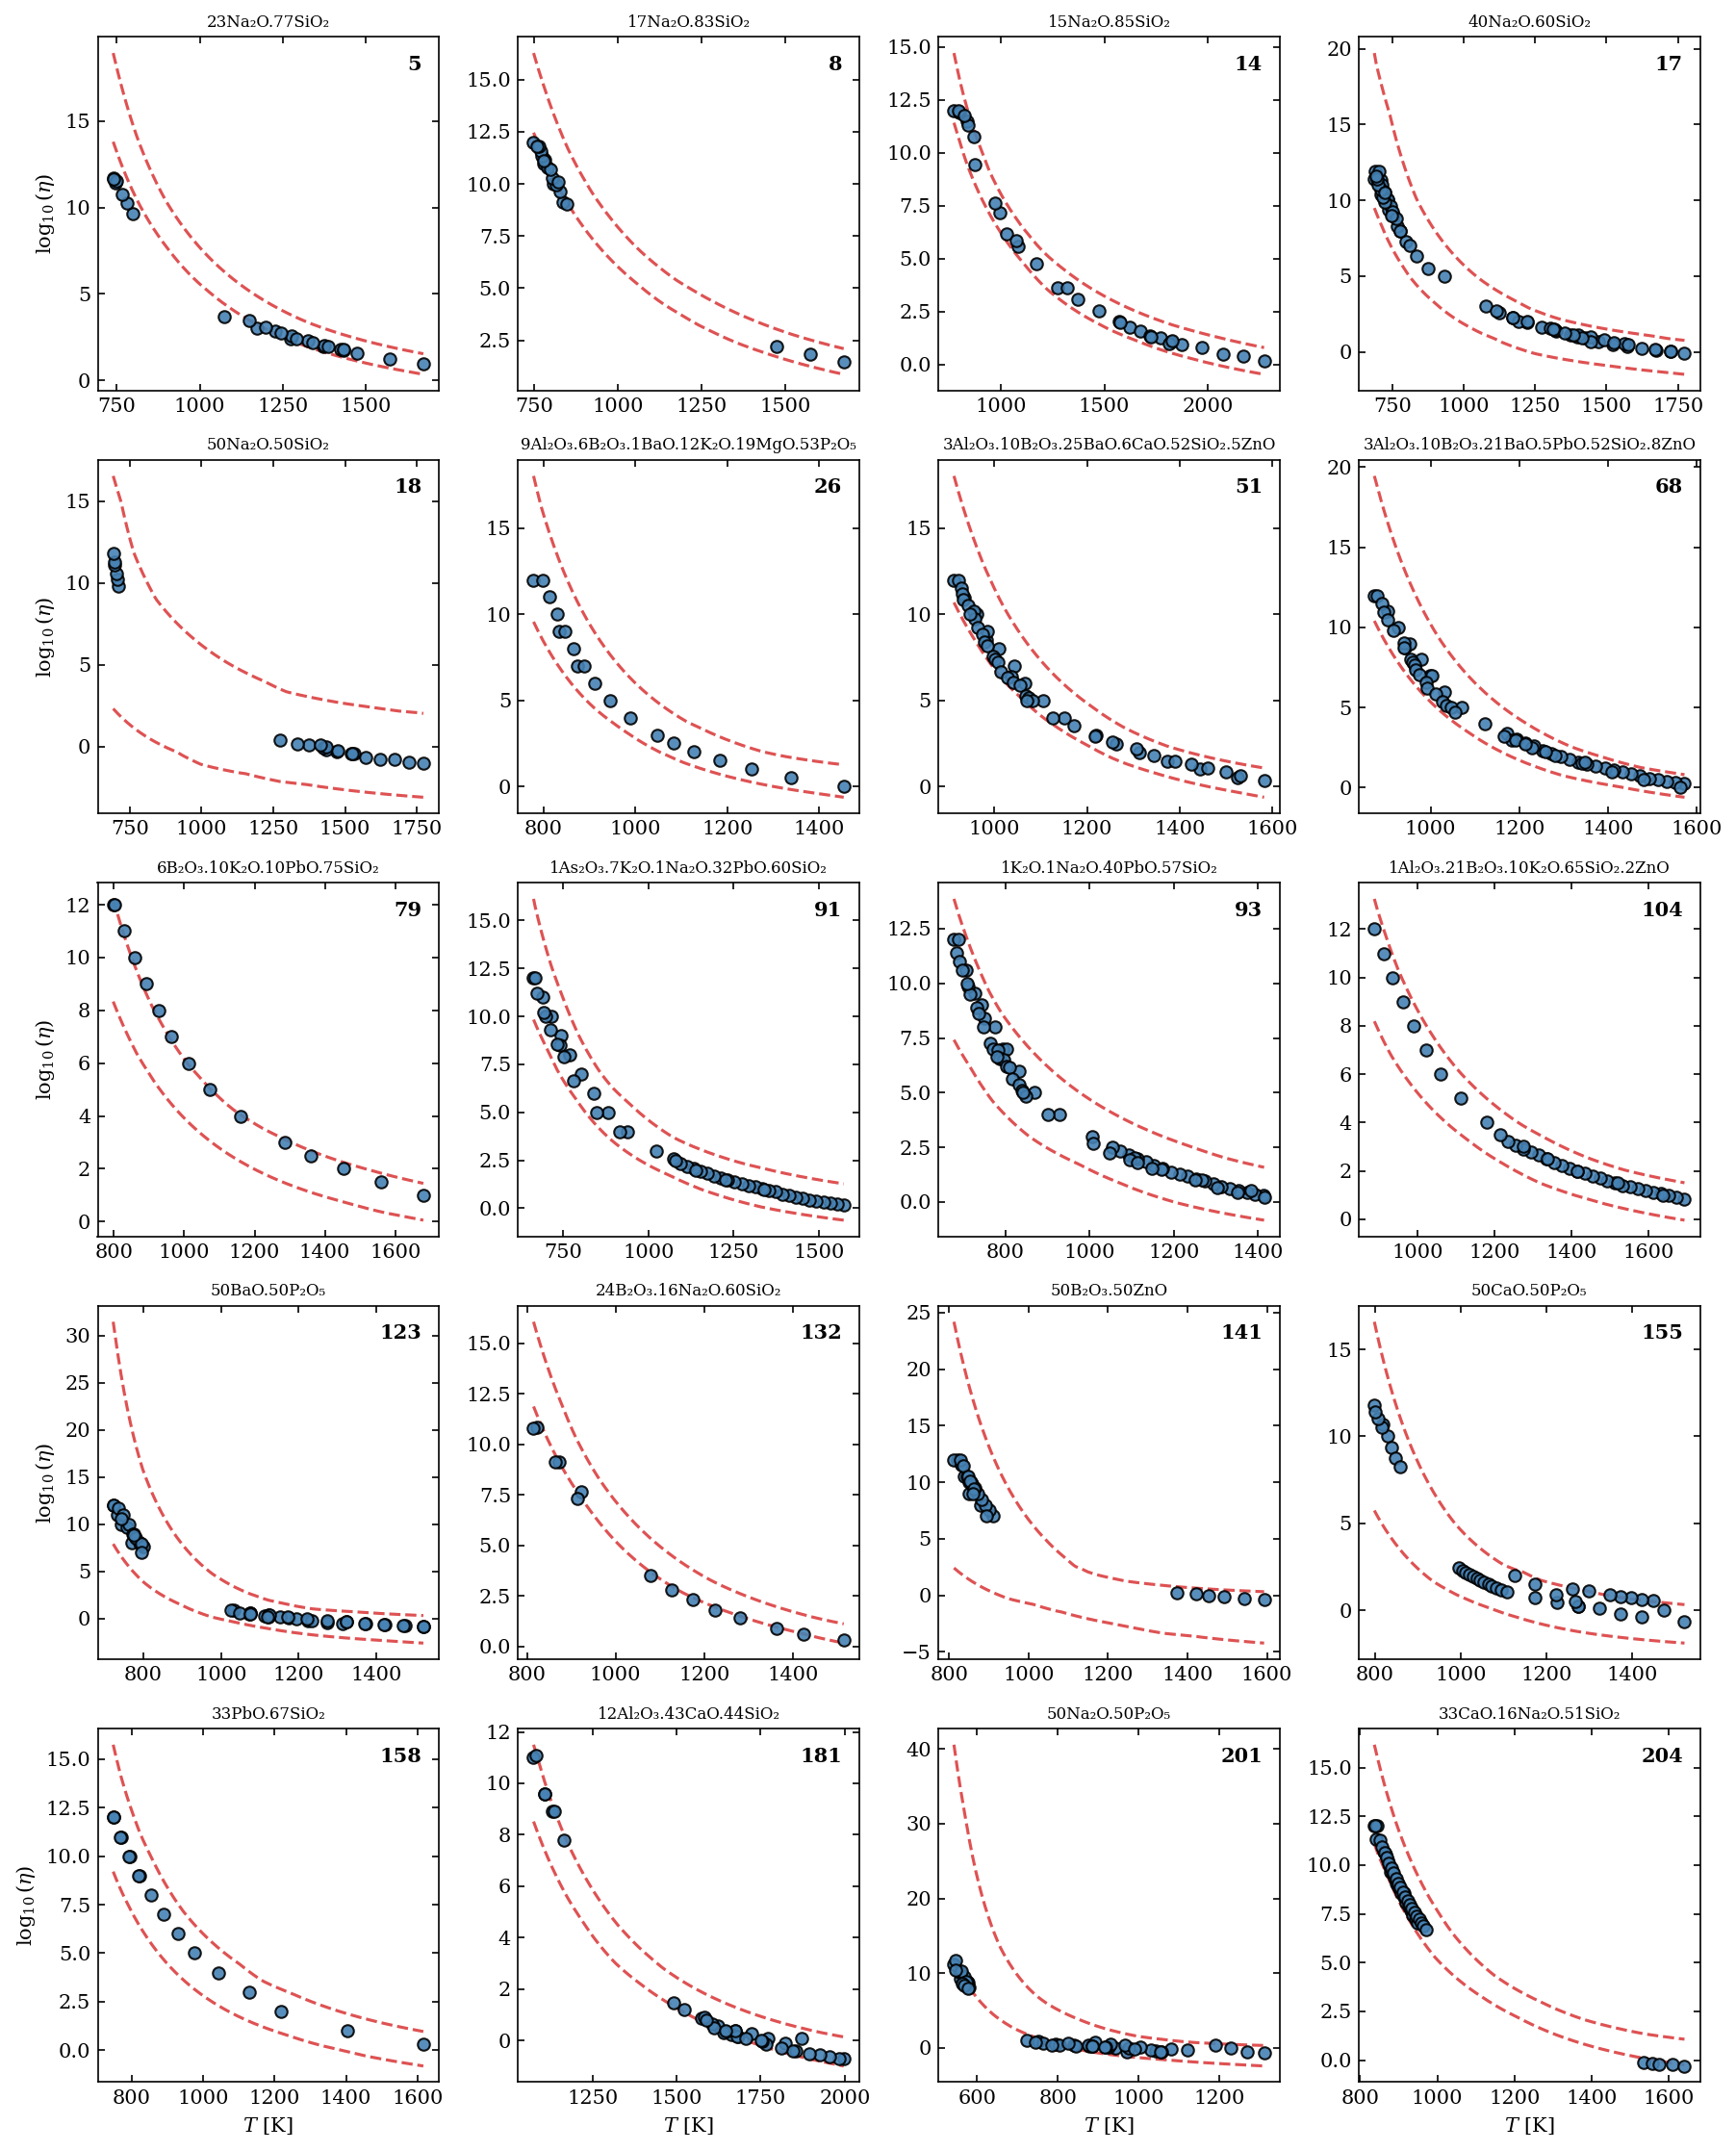

In [34]:
# Plotting test liquids viscosities with uncertainty bars

spcr_model_base = MultiOutputRegressor(
    CustomSupervisedPCR(n_components=10, variance_threshold=1e-4)
)

predictions_df, distributions_dict = generate_bootstrap_predictions(
    base_model=spcr_model_base,
    X_train=X_train_scaled,
    y_train=y_train_scaled,
    X_test=X_test_scaled,
    y_scaler=y_scaler,
    n_estimators=100
)

viscosity_plots_path = plots_path / "test_viscosity_plots"
viscosity_plots_path.mkdir(parents=True, exist_ok=True)

plot_viscosity_grids_bootstrap(
    viscosity_df=raw_data,
    distributions_dict=distributions_dict,
    names_dict=glass_names_dict,
    save_dir=viscosity_plots_path,
    confidence=95.0
)